In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from tqdm import *
from numpy.linalg import eigh
import matplotlib.pyplot as plt

In [2]:
def concat_model_4fold(test_path, res_path):
    market = 'ALL'
    model_res = []
    for valid_period in ['validperiod1', 'validperiod2', 'validperiod3', 'validperiod4']:
        data_path = rf"{test_path}/{market}-{valid_period}"
        date_list = list(set([x[:8] for x in os.listdir(data_path)]))
        date_list.sort()
        all_res = []
        for date in date_list:
            date_res = pd.read_pickle(f'{data_path}/{date}.pkl').T
            date_res.index = [date] * len(date_res)
            all_res.append(date_res)
        all_res = pd.concat(all_res, axis=0).sort_index()
        all_res.index.name = "date"
        all_res = all_res.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
        model_res.append(all_res)
        
    model_res = sum(model_res)
    model_res.reset_index().to_feather(rf"{res_path}/{market}_all_score.fea")
    return model_res

# 根据模型打分获取对应的label_ret和ic
def get_ret_ic(score, ret_data, liquid_data, start='20230101', end='20250630', money=1.5e9, print_quarterly=False):
    model_score = score.copy()
    label_ret = []
    ic = []
    datelist = []
    # 这是一段日度调仓计算日度收益率的代码
    for date in model_score.loc[start:end].index:
        datelist.append(date)
        code_rank = model_score.loc[date].sort_values(ascending=False)
        ret = ret_data.loc[date].reindex(code_rank.index).fillna(0) * 100
        liquid = liquid_data.loc[date].reindex(code_rank.index).fillna(0)
        total_hold = 0
        total_earned = 0
        for num,code in enumerate(code_rank.index):
            if num >= 500:
                break
            if (money - total_hold) < 1:
                break
            hold_money = min(money - total_hold, liquid[code])
            total_hold += hold_money
            total_earned += ret[code] * hold_money
        total_ret = total_earned / money
        label_ret.append(total_ret)
        ic.append(code_rank.corr(ret))
    ic = pd.Series(ic, index=datelist, dtype='float')
    label_ret = pd.Series(label_ret, index=datelist, dtype='float')
    if print_quarterly:
        print_quarterly_metrics(label_ret, ic)
    return label_ret, ic

def print_quarterly_metrics(ret, ic):
    """打印每个季度的收益和IC指标"""
    ret_series = ret.copy()
    ic_series = ic.copy()
    ret_series.index = pd.to_datetime(ret_series.index)
    ic_series.index = pd.to_datetime(ic_series.index)
    quarterly_ret = ret_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ic = ic_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ret.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ret.index]
    quarterly_ic.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ic.index]
    quarterly_df = pd.DataFrame({
        '季度平均收益(%)': quarterly_ret.round(4),
        '季度平均IC': quarterly_ic.round(4)
    })
    print("\n===== 季度表现指标 =====")
    print(quarterly_df)
    print("=======================\n")

def get_metrics(score, ret_data, liquid_data, start='20230101', end='20250630', money=1.5e9, print_quarterly=True):
    ret_list, ic_list = get_ret_ic(score, ret_data, liquid_data, start=start, end=end, money=money, print_quarterly=print_quarterly)
    # 当前模型评价
    score_metrics = {
        "IC": ic_list.mean(),
        "ICIR": ic_list.mean() / ic_list.std() if ic_list.std() != 0 else 0,
        "top_return": ret_list.mean(),
        "top_return_stability": ret_list.mean() / ret_list.std() if ret_list.std() != 0 else 0
    }
    return score_metrics

def print_metrics(model_metrics, bench_metrics=None, title="模型评估结果"):
    metric_keys = list(model_metrics.keys())
    df = pd.DataFrame(index=metric_keys)
    df.index.name = "指标"
    df["模型值"] = [model_metrics[k] for k in metric_keys]
    if bench_metrics is not None:
        df["基准值"] = [bench_metrics.get(k, None) for k in metric_keys]
        df["提升值"] = ((df["模型值"] - df["基准值"]) / df["基准值"]) * 100
    print(f"\n{title}")
    print(df.round(4))

def plot_model(model_score, bench_score, ret_data, liquid_data, start='20230101', end='20250630', money=1.5e9):
    model_ret, _ = get_ret_ic(model_score, ret_data, liquid_data, start=start, end=end, money=money, print_quarterly=False)
    model_ret = model_ret/100
    bench_ret, _ = get_ret_ic(bench_score, ret_data, liquid_data, start=start, end=end, money=money, print_quarterly=False)
    bench_ret = bench_ret/100

    dates = model_ret.index.tolist()
    seen_months = set()
    month_ticks = []
    month_labels = []
    for i, d in enumerate(dates):
        month = d[:6] 
        if month not in seen_months:
            seen_months.add(month)
            month_ticks.append(i)
            month_labels.append(d)

    # 1. 绘制每日收益率曲线
    plt.figure(figsize=(12, 6))
    plt.plot(dates, model_ret.cumsum(), label='model', color='blue')
    plt.plot(dates, bench_ret.cumsum(), label='bench', color='orange')
    plt.title('Cumulative Return Of Model & Bench', fontsize=14)
    plt.ylabel('Cumulative Return(%)', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 2. 绘制相对提升
    plt.figure(figsize=(12, 6))
    relative_improvement = model_ret - bench_ret
    plt.plot(dates, relative_improvement.cumsum(), label='model', color='blue')
    plt.title('Relative Iprovement', fontsize=14)
    plt.ylabel('Relative Iprovement(%)', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

def diversity_entropy(score):
    """
    计算 DE
    """
    if isinstance(score, pd.DataFrame):
        score = score.values
    m = score.shape[1]
    cov_matrix = np.cov(score, rowvar=False)
    eigenvalues, _ = eigh(cov_matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]
    normalized_eigenvalues = eigenvalues / (np.sum(eigenvalues) + 1e-10)
    entropy = 0
    for p in normalized_eigenvalues:
        if p > 1e-10:  # 只对非零概率计算
            entropy -= p * np.log(p)
    de = entropy / np.log(m)
    return de

def ensemble_scores(*dfs):
    """
    输入：任意数量的打分 DataFrame（index=日期，columns=股票）
    输出：拼接后的 DataFrame，columns=score1, score2, ...
    """
    result_list = []
    for i, df in enumerate(dfs, 1):
        df_norm = df.copy()
        df_norm = df_norm.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
        df_norm = df_norm.stack().rename(f"score{i}")
        result_list.append(df_norm)
    result = pd.concat(result_list, axis=1)
    return result.dropna()

# Bench_Mark_share1（5sub_score）

In [3]:
# # 标签
# label_path = rf"/project/model_share/share_1/label_data"
# label_name = rf'label1'
# # 流动性数据
# liquid_path = rf'/project/model_share/share_1/label_data'
# liquid_name = rf'can_trade_amt1'
# class params:
#     liquid_data = pd.read_feather(rf"{liquid_path}/{liquid_name}.fea").set_index("index")
#     ret_data = pd.read_feather(rf"{label_path}/{label_name}.fea").set_index("index")
    
# # bench打分评估
# bench1 = pd.read_feather(rf'/project/bench_remote/label1/bench_1.fea').set_index('date')
# bench2 = pd.read_feather(rf'/project/bench_remote/label1/bench_2.fea').set_index('date')
# bench3 = pd.read_feather(rf'/project/bench_remote/label1/bench_3.fea').set_index('date')
# bench4 = pd.read_feather(rf'/project/bench_remote/label1/bench_4.fea').set_index('date')
# bench5 = pd.read_feather(rf'/project/bench_remote/label1/bench_5.fea').set_index('date')
# bench6 = pd.read_feather(rf'/project/bench_remote/label1/bench_6.fea').set_index('date')

# bench_all = ensemble_scores(bench1, bench2, bench3, bench4, bench5, bench6)
# de_series = bench_all.groupby('date').apply(diversity_entropy)
# print(f'现有子模型的多样性熵：{de_series.mean()}')
# print('各子模型之间的相关性：')
# print(bench_all.groupby('date').corr().unstack().mean().unstack())

# bench_all = bench_all.mean(axis=1).unstack()
# bench_all_metrics = get_metrics(bench_all, params.ret_data, params.liquid_data, start='20230101', end='20250630', money=1.5e9, print_quarterly=True)
# print_metrics(bench_all_metrics)

# Bench_Mark_share2(5sub_score)

In [4]:
# 标签
label_path = rf'/project/model_share_remote/share_2/label_data'
label_name = rf'label2'
# 流动性数据
liquid_path = rf'/project/model_share_remote/share_2/label_data'
liquid_name = rf'can_trade_amt2'
class params:
    liquid_data = pd.read_feather(rf"{liquid_path}/{liquid_name}.fea").set_index("index")
    ret_data = pd.read_feather(rf"{label_path}/{label_name}.fea").set_index("index")
    
# bench打分评估
bench1 = pd.read_feather(rf'/project/bench_remote/label2/bench_1.fea').set_index('date')
bench2 = pd.read_feather(rf'/project/bench_remote/label2/bench_2.fea').set_index('date')
bench3 = pd.read_feather(rf'/project/bench_remote/label2/bench_3.fea').set_index('date')
bench4 = pd.read_feather(rf'/project/bench_remote/label2/bench_4.fea').set_index('date')
bench5 = pd.read_feather(rf'/project/bench_remote/label2/bench_5.fea').set_index('date')
bench6 = pd.read_feather(rf'/project/bench_remote/label2/bench_6.fea').set_index('date')

bench_all = ensemble_scores(bench1, bench2, bench3, bench4, bench5, bench6)
de_series = bench_all.groupby('date').apply(diversity_entropy)
print(f'现有子模型的多样性熵：{de_series.mean()}')
print('各子模型之间的相关性：')
print(bench_all.groupby('date').corr().unstack().mean().unstack())

bench_all = bench_all.mean(axis=1).unstack()
bench_all_metrics = get_metrics(bench_all, params.ret_data, params.liquid_data, start='20230101', end='20250630', money=4e9, print_quarterly=True)
print_metrics(bench_all_metrics)

现有子模型的多样性熵：0.49596905724985724
各子模型之间的相关性：
          score1    score2    score3    score4    score5    score6
score1  1.000000  0.672345  0.671901  0.562176  0.596344  0.672011
score2  0.672345  1.000000  0.869550  0.771866  0.739411  0.745406
score3  0.671901  0.869550  1.000000  0.776243  0.720937  0.740071
score4  0.562176  0.771866  0.776243  1.000000  0.717263  0.707606
score5  0.596344  0.739411  0.720937  0.717263  1.000000  0.770448
score6  0.672011  0.745406  0.740071  0.707606  0.770448  1.000000

===== 季度表现指标 =====
        季度平均收益(%)  季度平均IC
2023Q1     0.2940  0.1669
2023Q2     0.4500  0.1605
2023Q3     0.3164  0.1700
2023Q4     0.3465  0.1628
2024Q1     0.3699  0.1933
2024Q2     0.3007  0.1674
2024Q3     0.2655  0.1724
2024Q4     0.5493  0.1728
2025Q1     0.4013  0.1653
2025Q2     0.3891  0.1592


模型评估结果
                         模型值
指标                          
IC                    0.1691
ICIR                  2.2674
top_return            0.3675
top_return_stability  0.6675

# 模型样本内建议回测样例_share1为例

---单一模型评估---

===== 季度表现指标 =====
        季度平均收益(%)  季度平均IC
2023Q1     0.0766  0.0857
2023Q2     0.1299  0.0719
2023Q3     0.0883  0.0812
2023Q4     0.1114  0.0731
2024Q1     0.1215  0.0585
2024Q2     0.0258  0.0563
2024Q3     0.1001  0.0488
2024Q4     0.0714  0.0635
2025Q1     0.0600  0.0433
2025Q2     0.1289  0.0656


模型评估结果
                         模型值
指标                          
IC                    0.0649
ICIR                  0.7083
top_return            0.0915
top_return_stability  0.2649
---该模型与现有集成模型的相关性---
0.4869
---模型集成评估---
加入当前模型后的多样性熵：0.5748341089858051
当前模型与现有子模型之间的相关性：
          score1    score2    score3    score4    score5    score6    score7
score1  1.000000  0.656685  0.657048  0.549265  0.569530  0.647762  0.495803
score2  0.656685  1.000000  0.863333  0.760873  0.716895  0.729692  0.457390
score3  0.657048  0.863333  1.000000  0.765173  0.693570  0.722424  0.435850
score4  0.549265  0.760873  0.765173  1.000000  0.698839  0.698798  0.339997
score5  0.569530  0.71

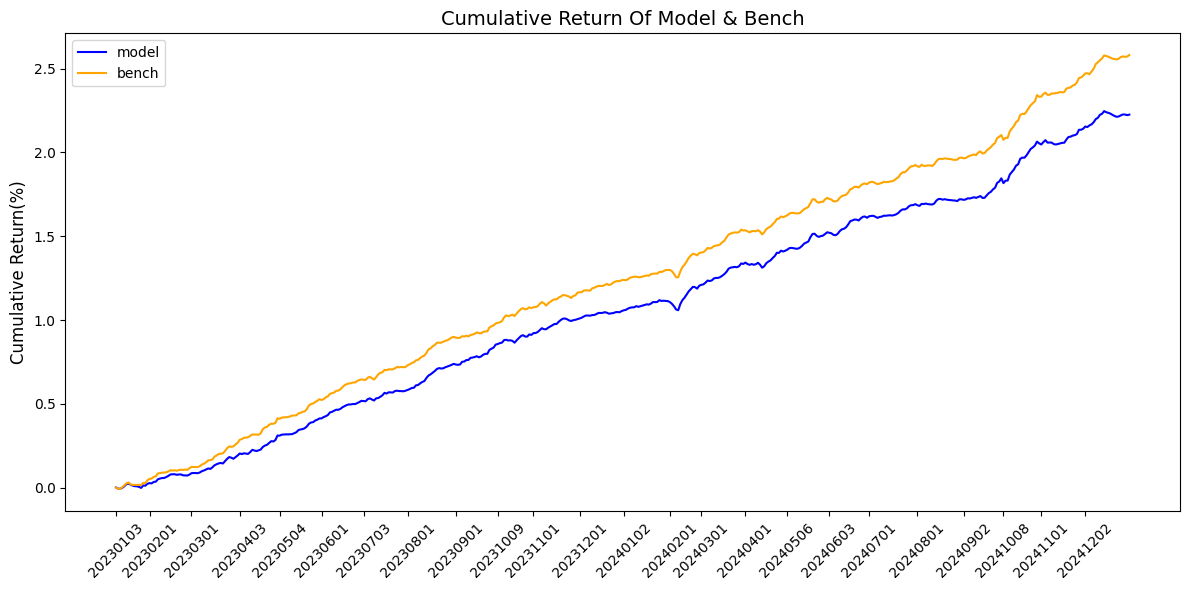

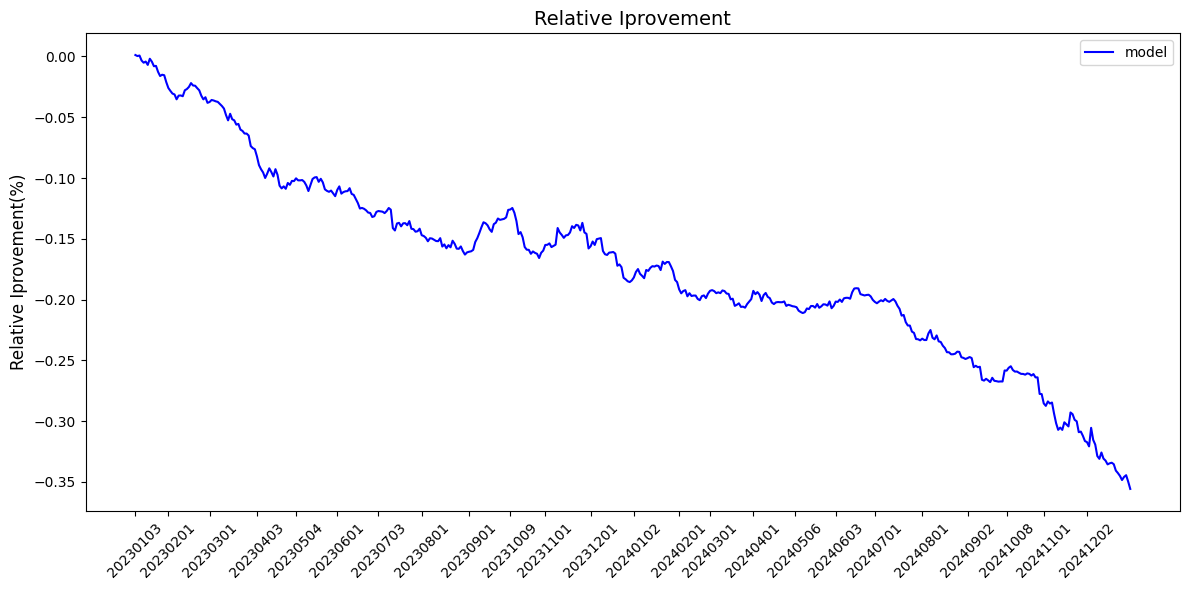

集成模型与现有模型的相关性：0.9886


In [5]:
# # 模型路径与结果路径
# root_path = rf'/home/datamake142/model_train_nn/share_1/20250212_实盘测试/shipan3'
# model_test_path = rf'{root_path}/model_test'
# model_res_path = rf'{root_path}/model_res'
# for path in [model_res_path]:
#     os.makedirs(path, exist_ok=True)

# # 收集模型训练结果
# score1 = concat_model_4fold(test_path=model_test_path, res_path=model_res_path) 

# score1_df = pd.read_csv(rf'/home/user165/workspace/quant/scores/mlp_spectral_v5_20260409_055017.csv')
# # score1_df = pd.read_csv(rf'hhx/code/model_XGBoost_v2/fac_all/scores/fac3001_20260224_224133.csv')
# score1_df['date'] = pd.to_datetime(score1_df['date']).dt.strftime('%Y%m%d')
# score1_df['Code'] = score1_df['Code'].astype(str).str.zfill(6)
# score1_df = score1_df.pivot(index='date', columns='Code', values='score')
# score1_df = score1_df.sort_index()
# score1_df.index.name = "date"

result_dir = r"/home/user165/workspace/quant/Graph/results"
score1_df2023q1_path = rf"{result_dir}/2023q1/score.feather"
score1_df2023q2_path = rf"{result_dir}/2023q2/score.feather"
score1_df2023q3_path = rf"{result_dir}/2023q3/score.feather"
score1_df2023q4_path = rf"{result_dir}/2023q4/score.feather"
score1_df2024q1_path = rf"{result_dir}/2024q1/score.feather"
score1_df2024q2_path = rf"{result_dir}/2024q2/score.feather"
score1_df2024q3_path = rf"{result_dir}/2024q3/score.feather"
score1_df2024q4_path = rf"{result_dir}/2024q4/score.feather"
score1_df2025q1_path = rf"{result_dir}/2025q1/score.feather"
score1_df2025q2_path = rf"{result_dir}/2025q2/score.feather"

score1_df2023q1 = pd.read_feather(score1_df2023q1_path) if os.path.exists(score1_df2023q1_path) else None
score1_df2023q2 = pd.read_feather(score1_df2023q2_path) if os.path.exists(score1_df2023q2_path) else None
score1_df2023q3 = pd.read_feather(score1_df2023q3_path) if os.path.exists(score1_df2023q3_path) else None
score1_df2023q4 = pd.read_feather(score1_df2023q4_path) if os.path.exists(score1_df2023q4_path) else None
score1_df2024q1 = pd.read_feather(score1_df2024q1_path) if os.path.exists(score1_df2024q1_path) else None
score1_df2024q2 = pd.read_feather(score1_df2024q2_path) if os.path.exists(score1_df2024q2_path) else None
score1_df2024q3 = pd.read_feather(score1_df2024q3_path) if os.path.exists(score1_df2024q3_path) else None
score1_df2024q4 = pd.read_feather(score1_df2024q4_path) if os.path.exists(score1_df2024q4_path) else None
score1_df2025q1 = pd.read_feather(score1_df2025q1_path) if os.path.exists(score1_df2025q1_path) else None
score1_df2025q2 = pd.read_feather(score1_df2025q2_path) if os.path.exists(score1_df2025q2_path) else None

score1_df = pd.concat([score1_df2023q1, score1_df2023q2, score1_df2023q3, score1_df2023q4, score1_df2024q1, score1_df2024q2, score1_df2024q3, score1_df2024q4, score1_df2025q1, score1_df2025q2], ignore_index=True)
# score1_df = pd.concat([score1_df2023q1, score1_df2023q2, score1_df2023q3, score1_df2023q4, score1_df2024q1, score1_df2024q2, score1_df2024q3, score1_df2024q4])
# score1_df = pd.read_feather(rf"/home/user165/workspace/quant/Graph/results/2023q1/score.feather")


score1_df['date'] = pd.to_datetime(score1_df['date']).dt.strftime('%Y%m%d')
score1_df = score1_df.pivot(index='date', columns='Code', values='score')
score1_df = score1_df.sort_index()
score1_df.index.name = "date"
score1 = score1_df

score1_dates = set(score1_df.index)
bench_dates = set(bench_all.index)
common_dates = sorted(score1_dates & bench_dates)
score1 = score1.loc[common_dates]
bench_all = bench_all.loc[common_dates]



# 单模型效果评估
print("---单一模型评估---")
score1_metrics = get_metrics(score1, params.ret_data, params.liquid_data, start='20230101', end='20250630', money=1.5e9, print_quarterly=True)
print_metrics(score1_metrics)
print("---该模型与现有集成模型的相关性---")
corr_with_bench = score1.reindex(columns=bench_all.columns, index=bench_all.index).corrwith(bench_all, axis=1)
print(f"{corr_with_bench.mean():.4f}")


print("---模型集成评估---")
bench_new = ensemble_scores(bench1, bench2, bench3, bench4, bench5, bench6, score1)
de_series = bench_new.groupby('date').apply(diversity_entropy)
print(f'加入当前模型后的多样性熵：{de_series.mean()}')
print('当前模型与现有子模型之间的相关性：')
print(bench_new.groupby('date').corr().unstack().mean().unstack())
print("---与现有子模型集成效果---")
bench_new_metrics = get_metrics(bench_new.mean(axis=1).unstack(), params.ret_data, params.liquid_data, start='20230101', end='20241231', money=1.5e9, print_quarterly=True)
print_metrics(bench_new_metrics, bench_all_metrics)
plot_model(bench_new.mean(axis=1).unstack(), bench_all, params.ret_data, params.liquid_data, start='20230101', end='20241231', money=1.5e9)

bench_new_mean = bench_new.mean(axis=1).unstack()
corr = bench_new_mean.corrwith(bench_all, axis=1).mean()
print(f"集成模型与现有模型的相关性：{corr:.4f}")



In [6]:
def construct_portfolio(score, ret_data, liquid_data, date, money=1.5e9):
    """
    构造单个交易日的投资组合
    """
    code_rank = score.loc[date].sort_values(ascending=False)
    ret = ret_data.loc[date].reindex(code_rank.index).fillna(0) * 100
    liquid = liquid_data.loc[date].reindex(code_rank.index).fillna(0)
    
    portfolio = []
    total_hold = 0
    total_earned = 0
    
    for num, code in enumerate(code_rank.index):
        if num >= 500:
            break
        if (money - total_hold) < 1:
            break
            
        hold_money = min(money - total_hold, liquid[code])
        total_hold += hold_money
        total_earned += ret[code] * hold_money
        
        portfolio.append({
            'code': code,
            'rank': num + 1,
            'score': code_rank[code],
            'return': ret[code],
            'liquid': liquid[code],
            'hold_money': hold_money,
            'weight': hold_money / money
        })
    
    portfolio_df = pd.DataFrame(portfolio)
    total_ret = total_earned / money
    
    return portfolio_df, total_ret

def compare_portfolios_detailed(bench_score, new_score, ret_data, liquid_data, sample_dates, money=1.5e9):
    """
    详细比较两个模型的投资组合差异
    """
    results = []
    
    for date in sample_dates:
        if date not in bench_score.index or date not in new_score.index:
            continue
            
        # 构造两个投资组合
        bench_portfolio, bench_ret = construct_portfolio(bench_score, ret_data, liquid_data, date, money)
        new_portfolio, new_ret = construct_portfolio(new_score, ret_data, liquid_data, date, money)
        
        # 分析持仓差异
        bench_stocks = set(bench_portfolio['code'])
        new_stocks = set(new_portfolio['code'])
        overlap = bench_stocks & new_stocks
        
        # 计算权重差异
        bench_weights = bench_portfolio.set_index('code')['weight']
        new_weights = new_portfolio.set_index('code')['weight']
        
        # 计算行业/特征差异（如果有相关数据）
        
        results.append({
            'date': date,
            'bench_ret': bench_ret,
            'new_ret': new_ret,
            'ret_diff': new_ret - bench_ret,
            'bench_portfolio_size': len(bench_portfolio),
            'new_portfolio_size': len(new_portfolio),
            'overlap_count': len(overlap),
            'overlap_ratio': len(overlap) / max(len(bench_portfolio), len(new_portfolio)),
            'bench_top10_avg_weight': bench_portfolio.nlargest(10, 'hold_money')['weight'].mean(),
            'new_top10_avg_weight': new_portfolio.nlargest(10, 'hold_money')['weight'].mean(),
            'bench_concentration': bench_portfolio['weight'].std(),
            'new_concentration': new_portfolio['weight'].std()
        })
    
    return pd.DataFrame(results)

# 分析具体某一天的持仓差异
def analyze_daily_portfolio_diff(date, bench_score, new_score, ret_data, liquid_data, money=1.5e9):
    """
    分析具体某一天的投资组合差异
    """
    print(f"\n=== 日期 {date} 投资组合详细分析 ===")
    
    bench_portfolio, bench_ret = construct_portfolio(bench_score, ret_data, liquid_data, date, money)
    new_portfolio, new_ret = construct_portfolio(new_score, ret_data, liquid_data, date, money)
    
    print(f"原模型收益: {bench_ret:.4f}%")
    print(f"新模型收益: {new_ret:.4f}%")
    print(f"收益差异: {new_ret - bench_ret:.4f}%")
    
    # 持仓重叠分析
    bench_stocks = set(bench_portfolio['code'])
    new_stocks = set(new_portfolio['code'])
    overlap = bench_stocks & new_stocks
    
    print(f"\n持仓分析:")
    print(f"原模型持仓数量: {len(bench_portfolio)}")
    print(f"新模型持仓数量: {len(new_portfolio)}")
    print(f"重叠股票数量: {len(overlap)}")
    print(f"重叠比例: {len(overlap) / max(len(bench_portfolio), len(new_portfolio)):.2%}")
    
    # 分析独有持仓的表现
    bench_only = bench_portfolio[~bench_portfolio['code'].isin(overlap)]
    new_only = new_portfolio[~new_portfolio['code'].isin(overlap)]
    
    if len(bench_only) > 0:
        bench_only_avg_ret = (bench_only['return'] * bench_only['weight']).sum() / bench_only['weight'].sum()
        print(f"\n原模型独有持仓 ({len(bench_only)}只):")
        print(f"平均收益: {bench_only_avg_ret:.4f}%")
        print(f"权重占比: {bench_only['weight'].sum():.2%}")
    
    if len(new_only) > 0:
        new_only_avg_ret = (new_only['return'] * new_only['weight']).sum() / new_only['weight'].sum()
        print(f"\n新模型独有持仓 ({len(new_only)}只):")
        print(f"平均收益: {new_only_avg_ret:.4f}%")
        print(f"权重占比: {new_only['weight'].sum():.2%}")
    
    # 重叠持仓的权重差异
    if len(overlap) > 0:
        overlap_bench = bench_portfolio[bench_portfolio['code'].isin(overlap)]
        overlap_new = new_portfolio[new_portfolio['code'].isin(overlap)]
        
        weight_diff = overlap_new.set_index('code')['weight'] - overlap_bench.set_index('code')['weight']
        print(f"\n重叠持仓权重差异:")
        print(f"最大增权: {weight_diff.max():.4%}")
        print(f"最大减权: {weight_diff.min():.4%}")
        print(f"权重差异标准差: {weight_diff.std():.4%}")
    
    return bench_portfolio, new_portfolio

# 执行分析
print("=== 投资组合差异分析 ===")

# 选择几个代表性日期进行分析
sample_dates = ['20230103', '20230307', '20230605', '20230927', '20231229']
valid_dates = [date for date in sample_dates if date in bench_all.index and date in bench_new.mean(axis=1).unstack().index]

print(f"分析日期: {valid_dates}")

# 详细分析某一天
if valid_dates:
    sample_date = valid_dates[2]  # 选择第三个日期作为示例
    bench_portfolio, new_portfolio = analyze_daily_portfolio_diff(
        sample_date, 
        bench_all, 
        bench_new.mean(axis=1).unstack(), 
        params.ret_data, 
        params.liquid_data
    )
    
    # 展示前10大持仓的差异
    print(f"\n=== 前10大持仓对比 ===")
    bench_top10 = bench_portfolio.nlargest(10, 'hold_money')[['code', 'rank', 'score', 'hold_money', 'weight']]
    new_top10 = new_portfolio.nlargest(10, 'hold_money')[['code', 'rank', 'score', 'hold_money', 'weight']]
    
    print("原模型前10大持仓:")
    print(bench_top10)
    
    print("\n新模型前10大持仓:")
    print(new_top10)
    
    # 计算多日统计
    print(f"\n=== 多日投资组合差异统计 ===")
    portfolio_comparison = compare_portfolios_detailed(
        bench_all,
        bench_new.mean(axis=1).unstack(),
        params.ret_data,
        params.liquid_data,
        valid_dates
    )
    
    print(portfolio_comparison.round(4))

=== 投资组合差异分析 ===
分析日期: ['20230103', '20230307', '20230605', '20230927', '20231229']

=== 日期 20230605 投资组合详细分析 ===
原模型收益: 1.0833%
新模型收益: 0.4863%
收益差异: -0.5971%

持仓分析:
原模型持仓数量: 21
新模型持仓数量: 42
重叠股票数量: 7
重叠比例: 16.67%

原模型独有持仓 (14只):
平均收益: 0.8716%
权重占比: 88.11%

新模型独有持仓 (35只):
平均收益: 0.1940%
权重占比: 88.11%

重叠持仓权重差异:
最大增权: 0.0000%
最大减权: 0.0000%
权重差异标准差: 0.0000%

=== 前10大持仓对比 ===
原模型前10大持仓:
      code  rank     score   hold_money    weight
0   603083     1  5.945784  200000000.0  0.133333
3   600072     4  4.831612  200000000.0  0.133333
4   605118     5  4.540580  200000000.0  0.133333
5   603933     6  4.440839  200000000.0  0.133333
2   603236     3  4.981182  186173910.0  0.124116
20  603918    21  3.183595   92262007.3  0.061508
14  600151    15  3.597916   66398375.0  0.044266
19  300913    20  3.297054   59520720.0  0.039680
1   603333     2  5.114940   51498960.0  0.034333
12  301360    13  3.774448   50193780.0  0.033463

新模型前10大持仓:
      code  rank     score    hold_money    weight
14 